# 10 — Training from Data: Gradient Descent, SGD and Mini-Batches

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *How do we minimize a loss that is an average over many samples, what do stochastic gradients buy, and what do they cost?*

A training loss is an average over $N$ samples, and $N$ can be very large. Computing the exact gradient then becomes the dominant cost, and an old idea from stochastic approximation takes over: *estimate* the gradient from a few samples. This notebook counts what the estimate costs, proves what it can and cannot guarantee, and ends where optimization meets generalization: stopping early, and noise as exploration.

### Table of Contents

1. **Training as the minimization of a finite sum** — per-sample losses, the laboratory problem
2. **Gradient descent, and what one step costs** — the cost unit: one per-sample gradient
3. **Stochastic gradient descent** — with and without replacement; unbiasedness
4. **Mini-batches and the variance of the stochastic gradient** — the $1/N_b$ law and the finite-population correction
5. **The convergence theorem of SGD, read exactly** — what it assumes, and what it does *not* conclude
6. **Laboratory: GD, SGD and mini-batch, compared fairly** — per iteration *and* per gradient evaluation
7. **Constant steps, the noise floor, and Robbins–Monro** — why the steps must decrease
8. **Early stopping** — choosing *when to stop* on the validation set
9. **Control ↔ ML**
10. **Proofs** — Theorem 1 and the finite-population correction
11. **Does noise help?** — Langevin dynamics, the Gibbs measure, and implicit regularization
12. **Common misconceptions**
13. **Key takeaways**
14. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

## Where are we?

> **Recap.** [Notebook 06](06_variational_principles_gradient_flows.ipynb): gradient descent $u_{k+1}=u_k-\eta\nabla J(u_k)$ is the explicit Euler scheme of the gradient flow. For a quadratic it converges iff $0<\eta<2/\lambda_{\max}$, and the number of steps grows with the condition number. [Notebook 09](09_machine_learning_foundations_generalization.ipynb): training minimizes the empirical risk $F$; the result is judged on a validation set, and reported once on a test set.

This notebook keeps the method of notebook 06 and changes the objective. A training loss is an **average over $N$ samples**, and $N$ can be very large. Computing $\nabla F$ exactly then becomes the dominant cost, and an old idea from stochastic approximation — Robbins and Monro, 1951 — takes over: *estimate* the gradient from a few samples. Everything turns on one question: what does the randomness of the estimate cost, and what does it buy?

## 1. Training as the minimization of a finite sum

Training a parametrized model on $N$ samples means solving
$$
\min_{w\in\mathbb R^D}F(w),\qquad F(w)=\frac1N\sum_{i=1}^Nf_i(w),
$$
where $f_i(w)=\ell(\hat y(x_i;w),y_i)$ is the loss on the $i$-th training sample. Two basic examples: *linear regression*, $f_i(w)=(w\cdot(x_i;1)-y_i)^2$, and *logistic regression* for labels $y_i\in\{0,1\}$,
$$
f_i(w)=-y_i\,\phi_i\cdot w+\log\big(1+e^{\phi_i\cdot w}\big),\qquad \phi_i=(x_i;1).
$$
Its gradient is $\nabla f_i(w)=\big(s(\phi_i\cdot w)-y_i\big)\phi_i$, with the sigmoid $s(z)=1/(1+e^{-z})$.

**The laboratory problem.** Throughout §§4–7 we train a regularized logistic regression on the E6 point cloud, with the fixed split of notebook 09 (72 training samples) and the per-sample losses
$$
f_i(w)=-y_i\,\phi_i\cdot w+\log\big(1+e^{\phi_i\cdot w}\big)+\tfrac\lambda2|w|^2,\qquad\lambda=10^{-2}.
$$
Its Hessian is $\frac1N\sum_is'(\phi_i\cdot w)\phi_i\phi_i^\top+\lambda I$ with $0<s'\le\frac14$. So $F$ is $\lambda$-strongly convex and its gradient is $L$-Lipschitz with
$$
L\le\tfrac14\lambda_{\max}\Big(\tfrac1N\textstyle\sum_i\phi_i\phi_i^\top\Big)+\lambda .
$$
It therefore has a unique minimizer $w^*$. We compute it once to machine precision by Newton's method, only to measure errors $F(w_k)-F^*$. For neural networks, by contrast, $F$ is not convex (notebook 09, §7), and the guarantees below are about stationary points, not minimizers.

In [2]:
# E6: the two-class point cloud of notebooks 00 and 09, and its fixed 72 / 24 / 24 split
X6 = torch.cat([torch.randn(60, 2) * 0.45 + torch.tensor([-0.6, 0.0]),
                torch.randn(60, 2) * 0.45 + torch.tensor([1.3, 0.3])]).numpy()
y6 = np.repeat([0.0, 1.0], 60)
rng = np.random.default_rng(0)                        # the only other source of randomness (shared with 09 and 11)
idx6 = rng.permutation(len(y6))
train6, val6, test6 = idx6[:72], idx6[72:96], idx6[96:]

# E9: 60 noisy samples of a smooth function the learner is not told, drawn from its own stream
# exactly as in notebook 09, so the data and the fixed 36 / 12 / 12 split are identical
target9 = lambda t: np.sin(2 * np.pi * t) * np.exp(-t)
rng9 = np.random.default_rng(3)
x9 = rng9.uniform(-1, 1, 60)
y9 = target9(x9) + 0.3 * rng9.standard_normal(60)
idx9 = rng9.permutation(60)
train9, val9, test9 = idx9[:36], idx9[36:48], idx9[48:]

In [3]:
Phi, y_tr = np.c_[X6, np.ones(len(y6))][train6], y6[train6]        # phi_i = (x_i; 1)
N, lam = len(y_tr), 1e-2
sig = lambda z: 1 / (1 + np.exp(-z))

def F(w):                                              # F(w) = (1/N) sum_i f_i(w), with the ridge term
    z = Phi @ w
    return np.mean(-y_tr * z + np.logaddexp(0, z)) + lam / 2 * w @ w

def batch_grad(w, idx):                                # mean of grad f_i(w) over the index array idx
    z = Phi[idx] @ w
    return ((sig(z) - y_tr[idx])[:, None] * Phi[idx]).mean(axis=0) + lam * w

L = np.linalg.eigvalsh(Phi.T @ Phi / N)[-1] / 4 + lam              # Lipschitz bound for grad F

w_star = np.zeros(3)                                               # reference minimizer by Newton's method
for _ in range(25):
    s = sig(Phi @ w_star)
    hessian = (Phi * (s * (1 - s))[:, None]).T @ Phi / N + lam * np.eye(3)
    w_star = w_star - np.linalg.solve(hessian, batch_grad(w_star, np.arange(N)))
F_star = F(w_star)
G_star = (sig(Phi @ w_star) - y_tr)[:, None] * Phi + lam * w_star  # all per-sample gradients at w*
sigma2_star = np.mean(np.sum((G_star - G_star.mean(axis=0)) ** 2, axis=1))
print(f"N = {N} training samples, D = 3 parameters, L <= {L:.4f}, strong convexity >= lambda = {lam}")
print(f"w* = {np.round(w_star, 4)},  F* = {F_star:.6f},  |grad F(w*)| = {np.linalg.norm(G_star.mean(axis=0)):.1e}")
print(f"variance of the per-sample gradients at w*: sigma^2(w*) = {sigma2_star:.4f}  (> 0: not an interpolating problem)")

N = 72 training samples, D = 3 parameters, L <= 0.3882, strong convexity >= lambda = 0.01
w* = [ 3.3781  0.1704 -1.039 ],  F* = 0.117762,  |grad F(w*)| = 2.3e-18
variance of the per-sample gradients at w*: sigma^2(w*) = 0.0069  (> 0: not an interpolating problem)


## 2. Gradient descent, and what one step costs

Full-batch gradient descent is
$$
w_{k+1}=w_k-\eta_k\,\frac1N\sum_{i=1}^N\nabla f_i(w_k).
$$
It is the method of notebook 06 applied to $F$, and everything proved there applies: for an $L$-smooth, strongly convex $F$ it converges linearly when $\eta$ is small enough compared with $1/L$. We do not repeat that analysis.

What is new is the **cost of one step**. To compare methods honestly, we fix a unit.

> **Cost unit.** One **per-sample gradient evaluation** is one computation of $\nabla f_i(w)$ for one index $i$ at one point $w$. A GD step costs $N$ units, an SGD step $1$, a mini-batch step $N_b$.

This counts arithmetic on samples, not seconds. Wall-clock time also depends on memory traffic and on vectorization: computing $N_b$ gradients together on a GPU can take about as long as computing one, which is one reason mini-batches are popular. In this notebook every comparison uses the sample-gradient count, which does not depend on the machine. For large $N$, full-batch GD faces three difficulties: each step is expensive, many samples carry redundant information, and the landscape may have bad local minima.

## 3. Stochastic gradient descent

**SGD.** At step $k$, choose an index $i_k$ uniformly in $\{1,\dots,N\}$ and update
$$
w_{k+1}=w_k-\eta_k\,g_k,\qquad g_k=\nabla f_{i_k}(w_k).
$$
There are two ways of drawing the indices:

- **with replacement:** the $i_k$ are independent and uniform, independent of everything before step $k$;
- **without replacement:** the indices are taken in a shuffled order; $N$ consecutive steps visit every sample exactly once and form an **epoch**. The order is reshuffled at the start of each epoch.

**Unbiasedness.** With replacement, $i_k$ is independent of $w_k$, so conditionally on $w_k$
$$
\mathbb E\big[g_k\,\big|\,w_k\big]=\sum_{i=1}^N\frac1N\,\nabla f_i(w_k)=\nabla F(w_k).
$$
The stochastic gradient is an unbiased estimate of the full gradient. This is the property every analysis below uses. Without replacement it holds for the first step of each epoch, but not for the later steps conditionally on the earlier ones (the visited samples cannot reappear). That is why the classical theory is stated for sampling with replacement.

Each SGD step costs one gradient evaluation instead of $N$. The price is noise: $g_k$ fluctuates around $\nabla F(w_k)$, and §5 shows that this noise prevents convergence unless the steps decrease.

## 4. Mini-batches and the variance of the stochastic gradient

**Mini-batch gradient descent** averages $N_b$ per-sample gradients:
$$
w_{k+1}=w_k-\eta_k\,\frac1{N_b}\sum_{i\in I_k}\nabla f_i(w_k),\qquad|I_k|=N_b .
$$
This reduces the variance of the updates. How much depends on the sampling convention. Fix $w$ and write
$$
\sigma^2(w)=\frac1N\sum_{i=1}^N\big|\nabla f_i(w)-\nabla F(w)\big|^2
$$
for the variance of one stochastic gradient (with replacement), and $g_B$ for the mini-batch mean.

> **Proposition 1 (variance of a mini-batch gradient).**
> *With replacement* ($N_b$ independent uniform indices): $\mathbb E\,|g_B-\nabla F(w)|^2=\dfrac{\sigma^2(w)}{N_b}$.
>
> *Without replacement* ($I_k$ a uniformly chosen subset of size $N_b$): $\mathbb E\,|g_B-\nabla F(w)|^2=\dfrac{\sigma^2(w)}{N_b}\cdot\dfrac{N-N_b}{N-1}$.
>
> *Interpretation:* averaging $N_b$ independent estimates divides the variance by $N_b$; drawing without replacement removes even more, and gives zero variance for $N_b=N$, where the mini-batch is the full batch.

*Proof with replacement.* The terms $\nabla f_{i_j}(w)-\nabla F(w)$, $j=1,\dots,N_b$, are independent, have mean zero and second moment $\sigma^2(w)$; the second moment of their average is $\sigma^2(w)/N_b$. The case without replacement, the *finite-population correction* $(N-N_b)/(N-1)$, is proved in §10. $\square$

The cell below checks both formulas at $w^*$ by sampling 4000 mini-batches for each batch size.

N_b =  1:  with replacement 0.00675 (formula 0.00695);  without 0.00689 (formula 0.00695)
N_b =  2:  with replacement 0.00367 (formula 0.00347);  without 0.00350 (formula 0.00342)
N_b =  4:  with replacement 0.00175 (formula 0.00174);  without 0.00169 (formula 0.00166)
N_b =  8:  with replacement 0.00086 (formula 0.00087);  without 0.00076 (formula 0.00078)
N_b = 18:  with replacement 0.00038 (formula 0.00039);  without 0.00030 (formula 0.00029)
N_b = 36:  with replacement 0.00020 (formula 0.00019);  without 0.00009 (formula 0.00010)
N_b = 72:  with replacement 0.00010 (formula 0.00010);  without 0.00000 (formula 0.00000)


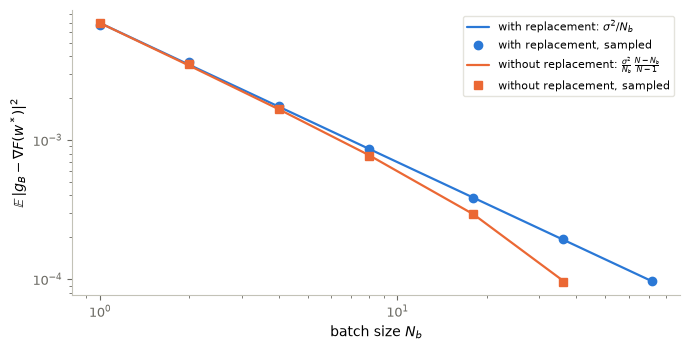

In [4]:
batch_sizes = np.array([1, 2, 4, 8, 18, 36, 72])
n_draws, mean_grad = 4000, G_star.mean(axis=0)
var_with_mc, var_without_mc = [], []
for B in batch_sizes:
    with_rep = np.array([G_star[rng.integers(0, N, size=B)].mean(axis=0) for _ in range(n_draws)])
    without = np.array([G_star[rng.permutation(N)[:B]].mean(axis=0) for _ in range(n_draws)])
    var_with_mc.append(np.mean(np.sum((with_rep - mean_grad) ** 2, axis=1)))
    var_without_mc.append(np.mean(np.sum((without - mean_grad) ** 2, axis=1)))
var_with = sigma2_star / batch_sizes
var_without = sigma2_star / batch_sizes * (N - batch_sizes) / (N - 1)
for B, a, b, c, d in zip(batch_sizes, var_with_mc, var_with, var_without_mc, var_without):
    print(f"N_b = {B:2d}:  with replacement {a:.5f} (formula {b:.5f});  without {c:.5f} (formula {d:.5f})")

fig, ax = P.panels(figsize=(7.0, 3.6))
ax.loglog(batch_sizes, var_with, color=P.BLUE, label=r"with replacement: $\sigma^2/N_b$")
ax.loglog(batch_sizes, var_with_mc, "o", color=P.BLUE, label="with replacement, sampled")
ax.loglog(batch_sizes[:-1], var_without[:-1], color=P.ORANGE,
          label=r"without replacement: $\frac{\sigma^2}{N_b}\,\frac{N-N_b}{N-1}$")
ax.loglog(batch_sizes[:-1], np.array(var_without_mc)[:-1], "s", color=P.ORANGE, label="without replacement, sampled")
P.label(ax, "batch size $N_b$", r"$\mathbb{E}\,|g_B-\nabla F(w^*)|^2$")
plt.show()

**Figure 1.** Variance of the mini-batch gradient of the E6 logistic problem at the minimizer $w^*$, against the batch size, for sampling with and without replacement: the formulas of Proposition 1 (lines) and averages over 4000 sampled batches (markers). The point $N_b=N=72$ without replacement, where the variance is exactly zero, cannot be drawn on a logarithmic axis.

*Interpretation.* The sampled variances follow the formulas. With replacement the variance falls like $1/N_b$, at every batch size. Without replacement it falls faster as $N_b$ approaches $N$ and vanishes at $N_b=N$. Note what the figure measures: the gradient is evaluated at $w^*$, where $\nabla F=0$, yet each single $\nabla f_i(w^*)$ is far from zero. **The stochastic gradient does not vanish at the minimizer.** This non-zero $\sigma^2(w^*)$ is the source of the noise floor of §7.

## 5. The convergence theorem of SGD, read exactly

The classical convergence result for SGD is easy to misquote, so we state it exactly as it is proved, with every hypothesis visible — and then read off what it does and does not say.

> **Theorem 1 (SGD with Robbins–Monro steps).**
> *Assumptions:* (A1) $F\ge F^*$; (A2) $\nabla F$ is $L$-Lipschitz; (A3) $\mathbb E\big[|\nabla f_{i_k}(w_k)-\nabla F(w_k)|^2\,\big|\,w_k\big]\le\sigma_g^2$ for every $k$; (A4) $0<\eta_k\le\bar\eta<2/L$ for all $k$; (A5) $i_k$ uniform on $\{1,\dots,N\}$ and independent of $i_1,\dots,i_{k-1}$; $w_1$ deterministic.
>
> *Conclusions:* with $c=1-\bar\eta L/2>0$,
>
> (i) $\mathbb E\big[F(w_{k+1})\,\big|\,w_k\big]\le F(w_k)-c\,\eta_k|\nabla F(w_k)|^2+\tfrac L2\eta_k^2\sigma_g^2\le F(w_k)+\eta_k\sigma_g^2$;
>
> (ii) for every $K$, with $S_K=\sum_{k=1}^K\eta_k$,
>
> $$\min_{1\le k\le K}\mathbb E\,|\nabla F(w_k)|^2\;\le\;\frac{1}{S_K}\sum_{k=1}^K\eta_k\,\mathbb E\,|\nabla F(w_k)|^2\;\le\;\frac{F(w_1)-F^*+\tfrac L2\sigma_g^2\sum_{k=1}^K\eta_k^2}{c\,S_K};$$
>
> (iii) if $\sum_k\eta_k=\infty$ and $\sum_k\eta_k^2<\infty$ (the **Robbins–Monro conditions**), the right-hand side of (ii) tends to $0$.
>
> *Interpretation:* SGD finds points with small expected squared gradient. If $F$ is moreover $\alpha$-strongly convex, $F(w)-F^*\le|\nabla F(w)|^2/(2\alpha)$ turns this into a bound on the expected optimality gap; without such an assumption the theorem says nothing quantitative about $F-F^*$, and for neural networks it concerns near-stationarity only.

The proof is three lines of algebra plus the unbiasedness of §3; it is written out in §10. Three details are easy to miss, and each is load-bearing:

- the one-step inequality (i) holds for the **conditional expectation** only — a single SGD step can increase $F$ by much more than $\eta_k\sigma_g^2$;
- the uniform bound $\sup_k\eta_k\le\bar\eta<2/L$ in (A4) is what produces *one* constant $c>0$ for all steps; under the Robbins–Monro conditions it is automatic ($\eta_k\to0$, so only finitely many steps exceed any level), but for other schedules — constant steps among them — it must be imposed;
- conclusion (ii) bounds the **minimum over $k$ of the expectations**, not the gradient of the last iterate; nothing here says that $w_K$ itself is close to stationary.

**Two consequences.**

- **Constant step: a bound that does not vanish.** With $\eta_k=\eta$ the weighted average in (ii) is the plain average, and $\frac1K\sum_{k\le K}\mathbb E|\nabla F(w_k)|^2\le\frac{F(w_1)-F^*}{c\,\eta K}+\frac{L\sigma_g^2}{2c}\,\eta$. The first term vanishes as $K\to\infty$; the second, **proportional to $\eta$**, does not. This is an *upper* bound: by itself it neither proves that the error stalls nor says where the iterates are. That a constant step does stall is proved exactly for a quadratic example in Exercise 2, where $\mathbb E(w_k-w^*)^2\to\eta s^2/(2-\eta)$, and observed in §7.
- **Why both conditions.** $\sum\eta_k=\infty$ lets the iterates travel arbitrarily far: the denominator grows. $\sum\eta_k^2<\infty$ makes the accumulated noise finite: the numerator stays bounded. A typical choice is $\eta_k=\eta_0/(1+k/k_0)$.

> **Remark (total work of GD versus SGD).** For a **strongly convex** $F$, the classical rates are $F(w_k)-F^*=O(\rho^k)$ for GD and $\mathbb E[F(w_k)-F^*]=O(1/k)$ for SGD with steps $\propto1/k$, with constants depending on the condition number. Counted in per-sample gradient evaluations, reaching accuracy $\varepsilon$ then costs about $N\log(1/\varepsilon)$ for GD and $1/\varepsilon$ for SGD: for large $N$ and moderate $\varepsilon$, SGD wins; for high accuracy, GD does. These are asymptotic statements, about the regime $\varepsilon\to0$ and $N$ large; we do not prove them here.

## 6. Laboratory: GD, SGD and mini-batch, compared fairly

All three methods minimize the *same* $F$ (same data, same $\lambda$), start from the *same* point $w=0$, and are run for the same budget of 40 epochs, that is, $40N$ per-sample gradient evaluations. The step sizes are fixed in advance from the bound $L$, not tuned on any data:

- **GD:** constant $\eta=1/L$, inside the range of notebook 06;
- **SGD** ($N_b=1$) and **mini-batch** ($N_b=8$), sampling with replacement: $\eta_k=\dfrac{1/L}{1+k\,N_b/N}$, which starts at $1/L$, whose denominator grows by one per epoch, and which satisfies the Robbins–Monro conditions and (A4).

We plot $F(w_k)-F^*$, averaged over 20 independent runs of each stochastic method, against the iteration count and against the gradient-evaluation count; shaded bands show the spread between runs.

> **Predict.** Which method is best per *iteration*? Which per *gradient evaluation* after one epoch? And after 40 epochs?

mean of F(w) - F* after [1, 2, 5, 10, 40] epochs (20 runs for the stochastic methods):
  GD                     [1.6e-01 8.7e-02 2.7e-02 6.9e-03 1.5e-05]
  SGD ($N_b=1$)          [3.9e-03 1.5e-03 1.1e-03 3.8e-04 7.2e-05]
  mini-batch ($N_b=8$)   [1.9e-02 7.4e-03 1.9e-03 7.1e-04 1.1e-04]


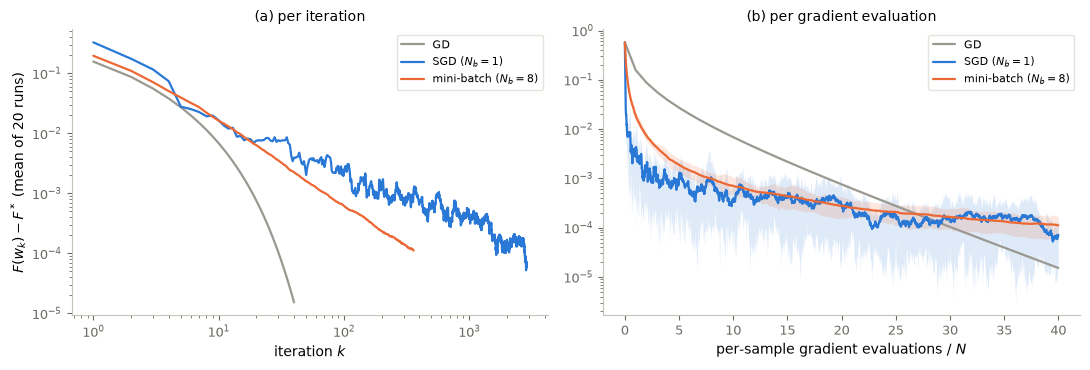

In [5]:
def sgd(w0, eta, n_steps, batch_size=1, sampling="with"):
    # eta: a float, or a function of the step counter k; returns the iterates w_0, ..., w_n
    w, ws, order, pos = w0.copy(), [w0.copy()], rng.permutation(N), 0
    for k in range(n_steps):
        if sampling == "with":
            idx = rng.integers(0, N, size=batch_size)
        elif sampling == "epoch":                       # without replacement, reshuffled every epoch
            if pos + batch_size > N:
                order, pos = rng.permutation(N), 0
            idx = order[pos:pos + batch_size]; pos += batch_size
        else:                                           # "full": deterministic gradient descent
            idx = np.arange(N)
        w = w - (eta(k) if callable(eta) else eta) * batch_grad(w, idx)
        ws.append(w.copy())
    return np.array(ws)

w0, epochs = np.zeros(3), 40
schedule = lambda B: (lambda k: (1 / L) / (1 + k * B / N))        # eta_k = (1/L) / (1 + k N_b / N)
methods = {"GD": (N, 1 / L), "SGD ($N_b=1$)": (1, schedule(1)), "mini-batch ($N_b=8$)": (8, schedule(8))}

mean_gap, band = {}, {}
for name, (B, eta) in methods.items():
    runs = 1 if name == "GD" else 20                              # GD is deterministic: one run
    gaps = [np.array([F(w) for w in sgd(w0, eta, epochs * N // B, B, "full" if name == "GD" else "with")]) - F_star
            for _ in range(runs)]
    mean_gap[name] = np.mean(gaps, axis=0)
    band[name] = np.quantile(gaps, [0.1, 0.9], axis=0)

checkpoints = [1, 2, 5, 10, 40]
print("mean of F(w) - F* after", checkpoints, "epochs (20 runs for the stochastic methods):")
for name, (B, _) in methods.items():
    values = [mean_gap[name][e * N // B] for e in checkpoints]
    print(f"  {name:22s}", np.array2string(np.array(values), formatter={"float_kind": lambda v: f"{v:.1e}"}))

fig, (ax1, ax2) = P.panels(2, figsize=(11.0, 3.8))
for name, color in zip(methods, (P.GREY, P.BLUE, P.ORANGE)):
    B = methods[name][0]
    ax1.loglog(np.arange(1, len(mean_gap[name])), mean_gap[name][1:], color=color, label=name)
    passes = np.arange(len(mean_gap[name])) * B / N               # gradient evaluations / N
    ax2.semilogy(passes, mean_gap[name], color=color, label=name)
    if name != "GD":
        ax2.fill_between(passes, band[name][0], band[name][1], color=color, alpha=0.15, lw=0)
P.label(ax1, "iteration $k$", r"$F(w_k)-F^*$ (mean of 20 runs)", title="(a) per iteration")
P.label(ax2, "per-sample gradient evaluations / $N$", title="(b) per gradient evaluation")
plt.show()

**Figure 2.** Regularized logistic regression on E6 (72 training samples), from $w=0$: GD with $\eta=1/L$, SGD and mini-batch ($N_b=8$) with $\eta_k=(1/L)/(1+kN_b/N)$, sampling with replacement; stochastic curves are means over 20 runs. *(a)* Gap against iterations. *(b)* Gap against per-sample gradient evaluations divided by $N$ ("equivalent data passes": with replacement, a pass need not visit every sample), with the 10–90% band of the 20 runs.

*Interpretation (answer to the prediction).* *Per iteration* (a), GD is ahead: each of its steps uses all 72 gradients. *Per gradient evaluation* (b), after one pass GD has taken one step, the mini-batch method 9 and SGD 72; the printed averages put the stochastic methods below GD early on. Later GD's linear convergence takes over: after 40 passes it is the most accurate of the three. An iteration count alone would hide all of this. The steps were fixed in advance; other schedules change the numbers, not the need to count evaluations. The asymptotic advantage of SGD from the remark in §5 is for large $N$; with $N=72$ it barely shows.

## 7. Constant steps, the noise floor, and Robbins–Monro

With a constant step, Theorem 1 only gives an upper bound with a term proportional to $\eta$; it does not prove that the error stalls. We now *observe* it, on a problem where $\sigma^2(w^*)>0$: at the minimizer the individual gradients do not vanish (Figure 1). The problem is genuinely stochastic at its solution. For a problem where every $\nabla f_i(w^*)=0$ (an *interpolating* problem, where one parameter fits all samples exactly) the floor would disappear; that special case must not be generalized.

We run SGD with two constant steps and with the Robbins–Monro schedule of §6, for 100 epochs, and average $F(w_k)-F^*$ over 10 runs, evaluated at the end of each epoch.

> **Predict.** If the constant step is divided by four, by roughly what factor does the floor go down? Does the decreasing schedule have a floor?

constant $\eta=1/L$                        mean gap over epochs 51-100: 5.13e-03
constant $\eta=1/(4L)$                     mean gap over epochs 51-100: 1.18e-03
Robbins–Monro $\eta_k=(1/L)/(1+k/N)$       mean gap over epochs 51-100: 8.05e-05


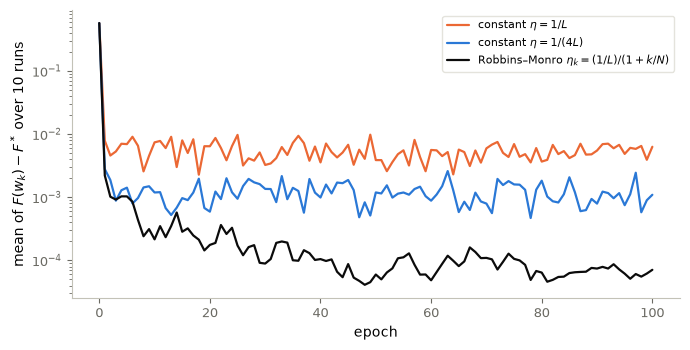

In [6]:
n_runs, n_epochs = 10, 100
settings = {r"constant $\eta=1/L$": 1 / L, r"constant $\eta=1/(4L)$": 1 / (4 * L),
            r"Robbins–Monro $\eta_k=(1/L)/(1+k/N)$": schedule(1)}
floors = {}
for name, eta in settings.items():
    runs = [[F(w) - F_star for w in sgd(w0, eta, n_epochs * N)[::N]] for _ in range(n_runs)]
    floors[name] = np.mean(runs, axis=0)
for name, curve in floors.items():
    print(f"{name:42s} mean gap over epochs 51-100: {curve[51:].mean():.2e}")

fig, ax = P.panels(figsize=(7.0, 3.6))
P.curves(ax, np.arange(n_epochs + 1),
         {name: (curve, color) for (name, curve), color in zip(floors.items(), (P.ORANGE, P.BLUE, P.INK))},
         log="y", xlabel="epoch", ylabel=r"mean of $F(w_k)-F^*$ over 10 runs")
plt.show()

**Figure 3.** SGD on the E6 logistic problem with a constant step $\eta=1/L$, a constant step $\eta=1/(4L)$, and the Robbins–Monro schedule $\eta_k=(1/L)/(1+k/N)$: optimality gap at the end of each epoch, averaged over 10 runs.

*Interpretation (answer to the prediction).* Both constant steps stall: after a fast initial decrease, the average gap stays at a level that no longer improves. Dividing the step by four lowers the floor by roughly the same factor: the floor shrinks with $\eta$, consistently with the bound of §5 — which is only an upper estimate: it neither proves the floor nor gives the factor. The decreasing schedule has no floor and keeps improving, slowly. This is the trade-off behind every learning-rate schedule: large steps make fast early progress and a high floor, small steps make slow progress and a low floor.

## 8. Early stopping: choosing *when to stop* on the validation set

A standard practical recommendation is to use a validation set to indicate **early stopping**. Training time is then a hyperparameter, exactly like the degree in notebook 09, and the same protocol applies: the stopping time is chosen on the validation set only, and the final evaluation uses data on which no decision depends.

**The experiment.** On E9, with the split of notebook 09, two over-parametrized models are trained by gradient descent from $w=0$ on the training MSE, with $\eta=1/L$: **(P)** a Legendre polynomial of degree 40 and **(G)** a combination of 41 Gaussian bumps $e^{-((x-c_j)/0.1)^2}$ with equally spaced centres; both have 41 coefficients for 36 training samples. For each, we record training and validation errors at 120 logarithmically spaced iterations up to $10^5$, and stop at the recorded iteration with the smallest validation error.

**An honest note on this laboratory.** When it was first designed, on another realization of E9, the lab contained (P) alone; the model selected on (P)'s validation curve looked fine there but failed badly on the 12-sample test split, because of an oscillation between two training points that no validation sample probed. The laboratory was then changed to include (G). Because the test split influenced that design decision, it is *development data*: we print its values, labelled as such, but they are not a final evaluation. The final evaluation uses a **fresh holdout** of 200 new samples from the same law, drawn only after both procedures, their hyperparameters and the selection rule were fixed, and evaluated once per procedure. Neither procedure is chosen on it.

> **Predict.** As training proceeds, the training error decreases. What does the validation error do, for each model?

P: polynomial, degree 40   stopping time (validation)     33: training MSE 0.045, validation MSE 0.104;  at 10^5: training 0.0187, validation 5.39
G: 41 Gaussian bumps       stopping time (validation)     12: training MSE 0.064, validation MSE 0.121;  at 10^5: training 0.0199, validation 6.33


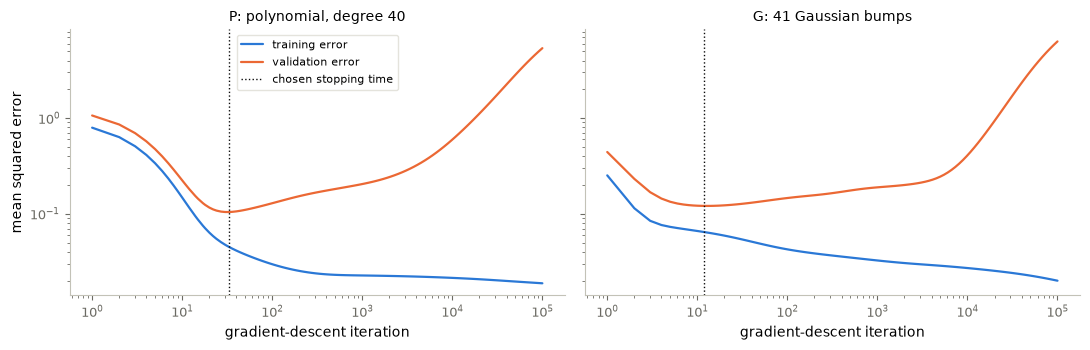

In [7]:
legendre = lambda x, d=40: np.polynomial.legendre.legvander(x, d)          # (P): Legendre basis, degree 40
bumps = lambda x: np.exp(-((x[:, None] - np.linspace(-1, 1, 41)) / 0.1) ** 2)   # (G): 41 Gaussian bumps
procedures = {"P: polynomial, degree 40": legendre, "G: 41 Gaussian bumps": bumps}
recorded = np.unique(np.round(np.logspace(0, 5, 120)).astype(int))
mse = lambda A, w, y: np.mean((A @ w - y) ** 2)

def early_stopping_run(features):
    # GD from w = 0 on the training MSE; the stopping time is chosen on the VALIDATION curve only
    A_tr, A_val = features(x9[train9]), features(x9[val9])
    y_tr9, y_val9 = y9[train9], y9[val9]
    eta = 1 / np.linalg.eigvalsh(2 * A_tr.T @ A_tr / len(y_tr9))[-1]       # 1 / L for this quadratic
    w, k, iterates, train_c, val_c = np.zeros(A_tr.shape[1]), 0, [], [], []
    for K in recorded:
        while k < K:
            w = w - eta * 2 * A_tr.T @ (A_tr @ w - y_tr9) / len(y_tr9)
            k += 1
        iterates.append(w.copy()); train_c.append(mse(A_tr, w, y_tr9)); val_c.append(mse(A_val, w, y_val9))
    stop = int(np.argmin(val_c))
    return {"train": np.array(train_c), "val": np.array(val_c), "stop": stop,
            "stopping_time": int(recorded[stop]), "w": iterates[stop]}

es = {name: early_stopping_run(f) for name, f in procedures.items()}
for name, r in es.items():
    print(f"{name:26s} stopping time (validation) {r['stopping_time']:6d}: training MSE {r['train'][r['stop']]:.3f}, "
          f"validation MSE {r['val'][r['stop']]:.3f};  at 10^5: training {r['train'][-1]:.4f}, validation {r['val'][-1]:.2f}")

fig, axes = P.panels(2, figsize=(11.0, 3.6), sharey=True)
for ax, (name, r) in zip(axes, es.items()):
    ax.loglog(recorded, r["train"], color=P.BLUE, label="training error")
    ax.loglog(recorded, r["val"], color=P.ORANGE, label="validation error")
    ax.axvline(r["stopping_time"], color=P.INK, ls=":", lw=1, label="chosen stopping time")
    P.label(ax, "gradient-descent iteration", title=name, legend=ax is axes[0])
axes[0].set_ylabel("mean squared error")
plt.show()

**Figure 4.** Gradient descent on the E9 training data for two over-parametrized models with 41 coefficients each, from $w=0$: (P) a degree-40 polynomial and (G) 41 Gaussian bumps. Training and validation errors against the iteration (logarithmic axes), and the stopping time chosen on each validation curve. No test or holdout error is plotted: none plays a role in the choice.

*Interpretation (answer to the prediction).* For both models the training error decreases monotonically, while the validation error first decreases and then rises: gradient descent fits the smooth part of the data first and the noise later, so *training time acts like model complexity*. The stopping time is chosen at the validation minimum, restricted to the 120 recorded iterations. How good the stopped models are on new data is a separate question, answered once below on the fresh holdout. Twelve validation samples cannot certify a model everywhere on $[-1,1]$: this is exactly what happened to (P) when the laboratory was designed.

In [8]:
# (1) Development data, ALREADY EXPOSED during the design of this laboratory: the 12-sample E9 test split.
dev_mse = {name: mse(procedures[name](x9[test9]), r["w"], y9[test9]) for name, r in es.items()}
# (2) Final evaluation, fixed before generation: a fresh holdout of 200 samples, evaluated once per procedure,
# from a child stream distinct from the holdout of notebook 09.
holdout_rng = rng9.spawn(2)[1]
x_new = holdout_rng.uniform(-1, 1, 200)
y_new = target9(x_new) + 0.3 * holdout_rng.standard_normal(200)
holdout_mse = {name: mse(procedures[name](x_new), r["w"], y_new) for name, r in es.items()}
for name in es:
    print(f"{name:26s} development test split (12, already exposed): {dev_mse[name]:.3f};   "
          f"fresh holdout (200, single evaluation): {holdout_mse[name]:.3f}")

P: polynomial, degree 40   development test split (12, already exposed): 0.191;   fresh holdout (200, single evaluation): 0.133
G: 41 Gaussian bumps       development test split (12, already exposed): 0.197;   fresh holdout (200, single evaluation): 0.147


**Reading the final evaluation.** The printed holdout values are the only numbers in this laboratory computed on data that influenced no decision; they were computed once, after both procedures were frozen, and neither procedure is chosen on them. The lesson that survives every realization of E9 is about the protocol, not about polynomials: twelve validation samples cannot certify a model everywhere on $[-1,1]$, a test set consulted during design stops being a test set, and the only honest final number is the one computed once, after all choices are fixed.

## 9. Control ↔ ML

- **GD is explicit Euler.** **DIRECT CONNECTION** (notebook 06): GD discretizes the gradient flow $w'=-\nabla F(w)$ in the time $\tau=k\eta$.
- **SGD as a noisy Euler scheme.** **MATHEMATICAL ANALOGY.** With $g_k=\nabla F(w_k)+\xi_k$, $\mathbb E\xi_k=0$, SGD is the Euler scheme perturbed by $-\eta_k\xi_k$; the perturbations accumulate like a random walk with variance of order $\sum\eta_k^2\sigma_g^2$, which is why $\sum\eta_k^2<\infty$ appears in Theorem 1. Section 11 makes the continuous-time picture precise, with Brownian noise in place of sampling noise.
- **Memory and damping.** **FORWARD CONNECTION.** [Notebook 11](11_optimization.ipynb) adds memory to the iteration: a discretized damped oscillator, the system of [notebook 05](05_feedback_stabilization.ipynb).
- **Training a controlled dynamics.** **FORWARD CONNECTION.** In [notebook 13](13_neuralodes.ipynb), the parameters of a residual network are controls, and training is this notebook's method applied to an optimal control problem.

## 10. Proofs: Theorem 1 and the finite-population correction

**Proof of Theorem 1.** Write $g_k=\nabla f_{i_k}(w_k)$ and $\mathbb E_k=\mathbb E[\,\cdot\mid w_k]$.

*Step 1 (descent lemma).* Since $\nabla F$ is $L$-Lipschitz, $F(v)\le F(w)+\langle\nabla F(w),v-w\rangle+\frac L2|v-w|^2$ for all $v,w$ (integrate $\frac{d}{dt}F(w+t(v-w))$ and use (A2); this is the descent lemma of notebook 06). With $v=w_{k+1}=w_k-\eta_kg_k$:
$$
F(w_{k+1})\le F(w_k)-\eta_k\langle\nabla F(w_k),g_k\rangle+\tfrac L2\eta_k^2|g_k|^2 .
$$

*Step 2 (conditional expectation).* By (A5), $\mathbb E_kg_k=\nabla F(w_k)$ (§3). Expanding the square, $\mathbb E_k|g_k|^2=|\nabla F(w_k)|^2+\mathbb E_k|g_k-\nabla F(w_k)|^2\le|\nabla F(w_k)|^2+\sigma_g^2$ by (A3). Hence
$$
\mathbb E_kF(w_{k+1})\le F(w_k)-\eta_k\big(1-\tfrac L2\eta_k\big)|\nabla F(w_k)|^2+\tfrac L2\eta_k^2\sigma_g^2 .
$$
By (A4), $1-\frac L2\eta_k\ge1-\frac L2\bar\eta=c>0$, which gives the first inequality of (i); the second follows from $c\ge0$ and $\frac L2\eta_k<1$.

*Step 3 (telescoping).* Take total expectations and sum over $k=1,\dots,K$; the values $\mathbb EF(w_k)$ telescope, and $\mathbb EF(w_{K+1})\ge F^*$ by (A1):
$$
c\sum_{k=1}^K\eta_k\,\mathbb E|\nabla F(w_k)|^2\le F(w_1)-F^*+\tfrac L2\sigma_g^2\sum_{k=1}^K\eta_k^2 .
$$
Dividing by $c\,S_K$ gives the weighted-average bound of (ii), and a weighted average is at least the minimum, which gives the first inequality of (ii). Under the Robbins–Monro conditions the numerator stays bounded and the denominator diverges, which is (iii). $\square$

Where each hypothesis entered: (A2) in Step 1, (A3) and (A5) in Step 2, (A4) to get one constant $c$ for all $k$, (A1) in Step 3. If only $\eta_k<2/L$ is assumed, without the uniform bound, the factors $1-\frac L2\eta_k$ could approach zero along a general schedule. Under the Robbins–Monro conditions this cannot happen: $\eta_k\to0$, so only finitely many steps exceed any given level, and their maximum is below $2/L$; hence $\sup_k\eta_k<2/L$ holds automatically.

**An almost-sure consequence.** Under the Robbins–Monro conditions, Step 3 gives $\sum_k\eta_k\,\mathbb E|\nabla F(w_k)|^2<\infty$. By Tonelli's theorem $\mathbb E\sum_k\eta_k|\nabla F(w_k)|^2<\infty$, so $\sum_k\eta_k|\nabla F(w_k)|^2<\infty$ almost surely; since $\sum_k\eta_k=\infty$, this forces $\liminf_k|\nabla F(w_k)|=0$ almost surely. This is still not a statement about the last iterate.

**The finite-population correction.** Let $a_i=\nabla f_i(w)-\nabla F(w)$, so $\sum_ia_i=0$ and $\frac1N\sum_i|a_i|^2=\sigma^2(w)$. For a uniformly chosen subset $I$ of size $N_b$, each index belongs to $I$ with probability $N_b/N$, and each pair $i\ne j$ with probability $\frac{N_b(N_b-1)}{N(N-1)}$. Then
$$
\mathbb E\Big|\sum_{i\in I}a_i\Big|^2=\frac{N_b}N\sum_i|a_i|^2+\frac{N_b(N_b-1)}{N(N-1)}\sum_{i\ne j}\langle a_i,a_j\rangle .
$$
Since $\sum_{i\ne j}\langle a_i,a_j\rangle=\big|\sum_ia_i\big|^2-\sum_i|a_i|^2=-N\sigma^2(w)$, the right side equals $N_b\sigma^2(w)\big(1-\frac{N_b-1}{N-1}\big)=N_b\sigma^2(w)\frac{N-N_b}{N-1}$. Dividing by $N_b^2$ gives Proposition 1 without replacement. $\square$

## 11. Does noise help? Langevin dynamics, the Gibbs measure, and implicit regularization

Practitioners often say that *SGD is less prone to overfitting because the data are chosen randomly*, that very precise optimizers converge to **sharp** minima that generalize worse than **flat** ones, and that in deep learning "noise helps". None of these is a theorem; Figure 4 above, for instance, shows overfitting by *deterministic* GD and its cure by early stopping, so stochasticity is not the only mechanism in play. But there is one setting where the value of noise can be stated and proved exactly: noise as **exploration** of a non-convex landscape.

Perturb the gradient flow of notebook 06 with white noise:
$$
dX_t = -\nabla F(X_t)\,dt + \sigma\,dW_t,
$$
with $W$ a $d$-dimensional Brownian motion and $\sigma>0$ the noise level. The Euler–Maruyama discretization with step $\eta$ is the algorithm we actually run,
$$
w_{k+1} = w_k - \eta\,\nabla F(w_k) + \sigma\sqrt{\eta}\,\xi_k, \qquad \xi_k \sim \mathcal{N}(0, I_d)\ \text{i.i.d.},
$$
a **Langevin-style noisy gradient step**: the noise scales as $\sqrt\eta$ because a Brownian increment over a time interval $\eta$ has standard deviation $\sqrt\eta$. Note the difference with SGD, whose random term $-\eta\xi_k$ scales with $\eta$: Brownian noise and mini-batch sampling noise are different constructions, and only the first is analysed here.

> **Theorem 2 (Gibbs measure).** Let $F$ be $C^2$ with global minimum value $F^\star$ and $\int e^{-F(x)}\,dx < \infty$, and let $0 < \sigma \le 1$. Then
>
> 1. the Gibbs density $\pi_\sigma(x) = Z_\sigma^{-1} e^{-2F(x)/\sigma^2}$ is stationary for the noisy gradient flow: if $X_0 \sim \pi_\sigma$, then $X_t \sim \pi_\sigma$ for all $t \ge 0$;
> 2. $\pi_\sigma$ concentrates on near-optimal points: for every $\varepsilon > 0$,
>
> $$\pi_\sigma\big(\{x : F(x) > F^\star + \varepsilon\}\big) \;\le\; C_\varepsilon\, e^{-\varepsilon/(2\sigma^2)} \;\xrightarrow[\sigma \to 0]{}\; 0 .$$

*Proof.* (1) The density $p_t$ of $X_t$ solves the Fokker–Planck equation
$$
\partial_t p = \nabla\cdot\Big(p\,\nabla F + \frac{\sigma^2}{2}\nabla p\Big).
$$
For $p = \pi_\sigma$ we have $\nabla \pi_\sigma = -\frac{2}{\sigma^2}\pi_\sigma \nabla F$, so the flux in brackets vanishes and $\partial_t p = 0$.

(2) Write $g = F - F^\star \ge 0$ and $A = \{g \le \varepsilon/4\}$, which has positive volume $|A|$ because $g$ is continuous and vanishes at a minimizer. Since $\sigma \le 1$, on $\{g > \varepsilon\}$ we have $e^{-2g/\sigma^2} = e^{-g/\sigma^2} e^{-g/\sigma^2} \le e^{-\varepsilon/\sigma^2} e^{-g}$, while on $A$ we have $e^{-2g/\sigma^2} \ge e^{-\varepsilon/(2\sigma^2)}$. Hence
$$
\pi_\sigma(g > \varepsilon) \le \frac{\int_{\{g > \varepsilon\}} e^{-2g/\sigma^2}\,dx}{\int_A e^{-2g/\sigma^2}\,dx} \le \frac{e^{-\varepsilon/\sigma^2}\int e^{-g}\,dx}{e^{-\varepsilon/(2\sigma^2)}\,|A|} = \underbrace{\frac{\int e^{-g}\,dx}{|A|}}_{C_\varepsilon}\, e^{-\varepsilon/(2\sigma^2)}. \qquad \square
$$

So at equilibrium the deepest basin dominates, wherever the iterates started, but a fixed $\sigma > 0$ keeps them spread around it: noise costs accuracy, exactly as the noise floor of §7 did. Small $\sigma$ sharpens $\pi_\sigma$ but slows the approach to equilibrium, since the expected time to cross an energy barrier of height $\Delta F$ grows like $e^{2\Delta F/\sigma^2}$ (Kramers' law). This is the case for **annealing**: start with large noise to explore, then decrease it — the Langevin analogue of the Robbins–Monro schedule. With the logarithmic schedule $\sigma_t^2 = c/\log t$ and $c$ large enough, the iterates converge in probability to the global minimizers (Geman and Hwang, 1986; Chiang, Hwang and Sheu, 1987).

Beyond this exact statement lies the open question of **implicit regularization**: among the many minimizers of an over-parametrized loss, which one does a given algorithm find, and why would it generalize? Precise answers exist for special cases — gradient descent from zero on least squares converges to the minimum-norm interpolant — but for neural networks the question is open, and the flat/sharp picture is a heuristic with known counterexamples. In this course these remain hypotheses, to be tested with the protocol of notebook 09.

**Code and animation.** Watch a deterministic and an annealed noisy update move through the same non-convex landscape: two cosine wells plus a quadratic confinement, started in the shallower basin.

In [9]:
from matplotlib.colors import LinearSegmentedColormap

f_land = lambda z: 0.08 * (z ** 2).sum(-1) - np.cos(z[..., 0]) - np.cos(z[..., 1])
df_land = lambda z: 0.16 * z + np.sin(z)

def euler_maruyama(sigma, x0=(7.0, 6.3), eta=0.1, n=600, seed=0):
    r, x, xs = np.random.default_rng(seed), np.array(x0, float), [np.array(x0, float)]
    for k in range(n):
        x = x - eta * df_land(x) + sigma(k) * np.sqrt(eta) * r.standard_normal(2)
        xs.append(x.copy())
    return np.array(xs)

n = 300
sigma = lambda k: 1.1 * (1 - k / 600)                               # cooled linearly towards zero
runs = [("gradient descent", euler_maruyama(lambda k: 0.0), P.BLUE),
        ("noisy gradient, annealed", euler_maruyama(sigma), P.ORANGE)]

g = np.linspace(-9, 9, 300); G1, G2 = np.meshgrid(g, g); Z = f_land(np.stack([G1, G2], -1))
fig, (ax, axr) = P.panels(2, figsize=(9, 3.6), ratios=[1, 1.05], dpi=85)
ax.contourf(G1, G2, Z, levels=np.linspace(Z.min(), 13, 10),
            cmap=LinearSegmentedColormap.from_list("land", ["#ffffff", "#b3b2a8"]))
ax.contour(G1, G2, Z, levels=[0.7, 3.5], colors="white", linewidths=0.9)   # two basin boundaries
ax.plot(0, 0, "*", color=P.INK, ms=11)
P.label(ax, "$w_1$", "$w_2$", xlim=(-9, 9), ylim=(-9, 9), equal=True)
axr.axhline(f_land(np.zeros(2)), ls=":", color=P.INK, lw=1)
P.label(axr, "iteration $k$", "$F(w_k)$", xlim=(0, n), ylim=(-2.4, 9))

artists = []
for name, path, col in runs:
    line, = ax.plot([], [], color=col, lw=1.2)
    dot, = ax.plot([], [], "o", color=col, ms=6, label=name)
    curve, = axr.plot([], [], color=col, lw=1.4)
    artists.append((path, line, dot, curve))
ax.legend(loc="upper left")

def update(i):
    k = 5 * i
    for path, line, dot, curve in artists:
        line.set_data(*path[:k + 1].T)
        dot.set_data([path[k, 0]], [path[k, 1]])
        curve.set_data(np.arange(k + 1), f_land(path[:k + 1]))

P.animate(fig, update, n // 5 + 1, interval=200)

*Interpretation.* The deterministic iterates converge to the nearest stationary point: they stay in the shallow basin where they started. The annealed noisy iterates first wander across basin boundaries — the white contours — and, as the noise is cooled, settle near the global minimizer (the star), at the price of never holding it exactly while $\sigma>0$. Exploration first, accuracy later: the same trade-off as the step-size schedules of §7, realized by the noise schedule instead.

## 12. Common misconceptions

**"SGD is faster than GD."** It depends on the unit and the accuracy. In Figure 2, GD was ahead per iteration throughout; per gradient evaluation the mini-batch method led early and GD at high accuracy. State the cost unit and the accuracy.

**"SGD converges to the minimizer with any small constant step."** In the examples it stalls at a level that shrinks with the step (Figure 3; exactly computed for the quadratic of Exercise 2), because the sample gradients do not vanish at the solution.

**"The theorem shows that the gradient of the last iterate goes to zero."** It bounds the minimum and a weighted average of $\mathbb E|\nabla F(w_k)|^2$ (Theorem 1), not the last iterate.

**"Without replacement is just a detail."** It changes the variance of mini-batches (Proposition 1) and breaks the conditional unbiasedness used in the classical proof.

**"The best stopping time is where the test error is smallest."** That uses the test set for a choice. Stop on the validation curve; evaluate the test set once (§8).

**"Noise is just a nuisance."** On non-convex landscapes, noise is also exploration: an annealed Langevin iteration can leave bad basins that trap deterministic GD (§11). The nuisance and the benefit are the same term, at different stages of training.

## 13. Key takeaways

1. Training minimizes a finite sum $F=\frac1N\sum_if_i$. Cost unit: one per-sample gradient; GD costs $N$ per step, SGD $1$, mini-batch $N_b$.
2. SGD uses $g_k=\nabla f_{i_k}(w_k)$, with $\mathbb E[g_k\mid w_k]=\nabla F(w_k)$ for uniform sampling with replacement.
3. Mini-batch variance: $\sigma^2/N_b$ with replacement, $\frac{\sigma^2}{N_b}\frac{N-N_b}{N-1}$ without.
4. Theorem 1: under (A1)–(A5), $\min_{k\le K}\mathbb E|\nabla F(w_k)|^2\le\dfrac{F(w_1)-F^*+\frac L2\sigma_g^2\sum\eta_k^2}{c\sum\eta_k}\to0$ when $\sum\eta_k=\infty$, $\sum\eta_k^2<\infty$.
5. Constant steps: the bound keeps a term proportional to $\eta$; in the examples the error stalls at a level that shrinks with $\eta$, because $\sigma^2(w^*)>0$.
6. Compare methods by gradient evaluations as well as iterations, from the same initialization, on the same objective.
7. Early stopping chooses the training time on the validation set; the test set is used once, afterwards.
8. Langevin noise with annealing explores non-convex landscapes and concentrates on the deepest basins (Gibbs measure); noise costs accuracy but buys exploration.

## 14. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Why unbiasedness matters. ★** (a) Suppose SGD draws index $i$ with probability $p_i>0$ instead of $1/N$. Show that $\nabla f_i$ is then a *biased* estimate of $\nabla F$, and that $\frac{1}{Np_i}\nabla f_i$ is unbiased. (b) What does biased SGD converge to, when it converges? Consider $N=2$, $f_1(w)=\frac12(w-1)^2$, $f_2(w)=\frac12(w+1)^2$, $p_1=0.9$, and the fixed points of the expected update. (c) Which step of the proof of Theorem 1 fails for a biased estimate?
2. **The noise floor, exactly. ★★** Let $f_i(w)=\frac12(w-c_i)^2$ in one dimension, with numbers $c_1,\dots,c_N$ that are not all equal, mean $\bar c$ and variance $s^2=\frac1N\sum_i(c_i-\bar c)^2>0$. (a) Show that $F$ is minimized at $w^*=\bar c$, that $L=1$, and that $\sigma^2(w^*)=s^2$. (b) For SGD with constant step $0<\eta<2$ and sampling with replacement, let $e_k=\mathbb E(w_k-w^*)^2$. Show that $e_{k+1}=(1-\eta)^2e_k+\eta^2s^2$, and deduce that $e_k\to\dfrac{\eta\,s^2}{2-\eta}$. (c) Interpret: what happens as $\eta\to0$, and for $s=0$? Check the limit numerically for $c=(0,1,2,3,4)$ and $\eta=0.1$.
3. **Constants in the theorem. ★★** (a) From the telescoped inequality of §10 (Step 3) with a constant step $\eta\le\bar\eta<2/L$, derive the estimate of §5 for $\frac1K\sum_{k\le K}\mathbb E|\nabla F(w_k)|^2$. (b) For a fixed budget of $K$ steps, choose $\eta$ to minimize the right-hand side, ignoring the constraint $\eta\le\bar\eta$, and show that the bound then decays like $K^{-1/2}$. (c) Explain why this does not contradict the faster convergence of GD in Figure 2.
4. **Which schedules are Robbins–Monro? ★★** For each schedule decide whether $\sum\eta_k=\infty$ and $\sum\eta_k^2<\infty$: (a) $\eta_k=\eta_0/k$; (b) $\eta_k=\eta_0/\sqrt k$; (c) $\eta_k=\eta_0/k^2$; (d) $\eta_k=\eta_0/(k\log(k+1))$; (e) $\eta_k=\eta_0$. For (b), which fails the second condition, show that the bound (ii) still tends to zero, like $(\log K)/\sqrt K$. What does (c) do in practice?
5. **With or without replacement? ★★★** Repeat the SGD run of §6 ($N_b=1$, the same schedule and budget) with `sampling="epoch"` (without replacement, reshuffling every epoch), for 20 runs each, and compare the mean gap $F(w)-F^*$ after 1, 5 and 40 epochs with sampling with replacement. Which converges faster on this problem? Relate your answer to Proposition 1 and to the loss of conditional unbiasedness discussed in §3.
6. **Batch size and the floor. ★★★** Run mini-batch SGD with the *constant* step $\eta=1/L$ and batch sizes $N_b=1,4,16$ for 60 epochs (sampling with replacement), and estimate the floor of each by averaging $F(w)-F^*$ over the last 30 epochs and 10 runs. How does the floor depend on $N_b$ at a fixed step? Compare with $\sigma_g^2\propto1/N_b$ in Theorem 1, and discuss what changes if the *budget of gradient evaluations*, rather than the number of steps, is fixed.
7. **Annealing schedules. ★★★** In the Langevin animation of §11, compare zero noise, constant noise $\sigma=1.1$, and the cooled schedule. Which paths leave the initial basin, and which settle near the global minimum? Then replace the linear cooling by $\sigma_k^2=c/\log(k+2)$ for a few values of $c$ and describe what changes.

In [10]:
# TODO: student exercise (Exercise 5)
# Use sgd(w0, schedule(1), 40 * N, batch_size=1, sampling="epoch") and the same call with
# sampling="with"; average F(w) - F_star over 20 runs at epochs 1, 5, 40.

def mean_gaps(sampling):
    ...  # your code here
    return None

## Where are we going?

GD and SGD follow the current gradient only; they have no memory. On ill-conditioned problems they zigzag across narrow valleys (notebook 06), and with noise they need decreasing steps. [Notebook 11](11_optimization.ipynb) adds two mechanisms: **memory**, through momentum, whose continuous model is the damped oscillator of [notebook 05](05_feedback_stabilization.ipynb); and **adaptivity**, through per-coordinate step sizes (AdaGrad, RMSProp, Adam). The comparisons there follow the rules of this notebook: same objective, same initialization, gradient-evaluation counts, and validation-only choices.

## References

1. H. Robbins, S. Monro, [*A stochastic approximation method*](https://doi.org/10.1214/aoms/1177729586), Annals of Mathematical Statistics **22** (1951), 400–407.
2. L. Bottou, F. E. Curtis, J. Nocedal, [*Optimization methods for large-scale machine learning*](https://doi.org/10.1137/16M1080173), SIAM Review **60** (2018), 223–311.
3. J. Nocedal, S. J. Wright, [*Numerical Optimization*](https://doi.org/10.1007/978-0-387-40065-5), 2nd ed., Springer, 2006.
4. S. Geman, C.-R. Hwang, [*Diffusions for global optimization*](https://doi.org/10.1137/0324060), SIAM Journal on Control and Optimization **24** (1986), 1031–1043.
5. T.-S. Chiang, C.-R. Hwang, S. J. Sheu, [*Diffusion for global optimization in $\mathbb R^n$*](https://doi.org/10.1137/0325042), SIAM Journal on Control and Optimization **25** (1987), 737–753.
6. N. S. Keskar, D. Mudigere, J. Nocedal, M. Smelyanskiy, P. T. P. Tang, [*On large-batch training for deep learning: generalization gap and sharp minima*](https://arxiv.org/abs/1609.04836), ICLR 2017.
7. C. Zhang, S. Bengio, M. Hardt, B. Recht, O. Vinyals, [*Understanding deep learning requires rethinking generalization*](https://arxiv.org/abs/1611.03530), ICLR 2017.